In [1]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
from src.bayesian_uplift import (
    build_pairwise_uplift,
    build_uplift_tables,
    fit_bayesian_views_model,
    plot_uplift_errorbars,
)
from src.half_life import (
    build_life_time_plot_data,
    estimate_life_time_linear,
    prepare_half_life_regression_data,
)
from src.popularity_insights import (
    build_content_spread_summary,
    build_tier_platform_metrics,
    prepare_popularity_tiers,
)

# Preproc

## Table of Contents
- [Preproc](#Preproc)
- [Insight Names](#Insight-Names)
- [Insight 1: Bayesian Uplift by Weekday and Format](#Insight-1:-Bayesian-Uplift-by-Weekday-and-Format)
- [Insight 2: Content Lifetime from Cohort Decay](#Insight-2:-Content-Lifetime-from-Cohort-Decay)
- [Insight 3: Platform Mix Across Popularity Tiers](#Insight-3:-Platform-Mix-Across-Popularity-Tiers)


In [3]:
video_performance_data = pd.read_csv("data/dataset_1_video_performance.csv")

video_performance_data["publish_date"] = pd.to_datetime(
    video_performance_data["publish_date"]
)
video_performance_data["publish_weekday"] = video_performance_data[
    "publish_date"
].dt.day_name()

In [4]:
video_performance_data.head()

,video_id,channel_id,platform,publish_date,publish_hour,duration_seconds,video_type,total_views,first_7d_views,first_30d_views,...,likes,comments,shares,dislikes,ad_impressions,engagement_rate,estimated_cpm,avg_view_duration_seconds,avg_percentage_viewed,publish_weekday
0,vid_1129600,channel_6357,YouTube,2025-12-02,16,260,Production,2,2.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.00,0.00,30.00,11.54,Tuesday
1,vid_1129712,channel_11257,YouTube,2026-02-22,12,NaN,Live,618,618.0,618.0,...,13.0,0.0,0.0,0.0,985.0,2.10,2.51,130.19,0.00,Sunday
2,vid_1127700,channel_11257,YouTube,2026-02-21,22,NaN,Live,5569,5569.0,5569.0,...,16.0,0.0,3.0,3.0,8115.0,0.34,3.54,340.63,0.00,Saturday
3,vid_1127705,channel_9356,YouTube,2025-12-02,17,247,Production,2,2.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,Tuesday
4,vid_1131233,channel_8327,YouTube,2025-12-21,10,NaN,Live,202,202.0,202.0,...,0.0,0.0,0.0,0.0,0.0,0.00,0.00,75.74,0.00,Sunday


In [5]:
assert video_performance_data.duplicated().sum() == 0

In [6]:
video_performance_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   video_id                   11500 non-null  object        
 1   channel_id                 11500 non-null  object        
 2   platform                   11500 non-null  object        
 3   publish_date               11500 non-null  datetime64[ns]
 4   publish_hour               11500 non-null  int64         
 5   duration_seconds           11154 non-null  object        
 6   video_type                 11500 non-null  object        
 7   total_views                11500 non-null  int64         
 8   first_7d_views             9703 non-null   float64       
 9   first_30d_views            9703 non-null   float64       
 10  watch_time_minutes         11500 non-null  float64       
 11  watch_time_7d              6703 non-null   float64       
 12  watc

In [7]:
video_cohort_data = pd.read_csv("data/dataset_2_cohort_analysis.csv")
video_cohort_data = video_cohort_data.drop_duplicates()
format_mapping = video_performance_data.set_index("video_id").video_type.to_dict()
video_cohort_data["video_type"] = video_cohort_data.video_id.map(format_mapping)
video_cohort_data.head()

,video_id,platform,publish_month,data_month,months_since_publish,views,watch_time_minutes,video_type
0,vid_1129712,YouTube,2026-02,2026-02,0,618,1341.0,Live
1,vid_1127700,YouTube,2026-02,2026-02,0,5569,31616.0,Live
2,vid_1127783,YouTube,2026-02,2026-02,0,1044,380.0,Short
3,vid_1126776,YouTube,2026-02,2026-02,0,3791,7361.0,Live
4,vid_1130008,YouTube,2026-02,2026-02,0,0,0.0,Live


In [8]:
video_cohort_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31536 entries, 0 to 31588
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   video_id              31536 non-null  object 
 1   platform              31536 non-null  object 
 2   publish_month         31536 non-null  object 
 3   data_month            31536 non-null  object 
 4   months_since_publish  31536 non-null  int64  
 5   views                 31536 non-null  int64  
 6   watch_time_minutes    31536 non-null  float64
 7   video_type            31536 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 2.2+ MB


In [9]:
assert video_cohort_data.duplicated().sum() == 0

In [10]:
cross_platform_data = pd.read_csv("data/dataset_3_cross_platform.csv")
cross_platform_data["publish_date"] = pd.to_datetime(
    cross_platform_data["publish_date"], errors="coerce"
)

In [11]:
cross_platform_data = cross_platform_data.drop_duplicates()
assert cross_platform_data.duplicated().sum() == 0

## Insight Names
- `Insight 1`: **Bayesian Uplift by Weekday and Format**
- `Insight 2`: **Content Lifetime from Cohort Analysis**
- `Insight 3`: **Platform Mix Across Popularity Tiers**


# Insight 1: Bayesian Uplift by Weekday and Format


### Intro
Insight 1 tests whether publish weekday and video format have a measurable impact on first 7-day views for YouTube content, using a hierarchical Bayesian model.


In [12]:
columns = [
    "video_id",
    "channel_id",
    "platform",
    "publish_weekday",
    "first_7d_views",
    "video_type",
]

insight_data = video_performance_data[columns]
insight_data = insight_data.dropna(subset="first_7d_views")

insight_data = insight_data[insight_data.first_7d_views != 0]
insight_data = insight_data[insight_data.platform == "YouTube"]

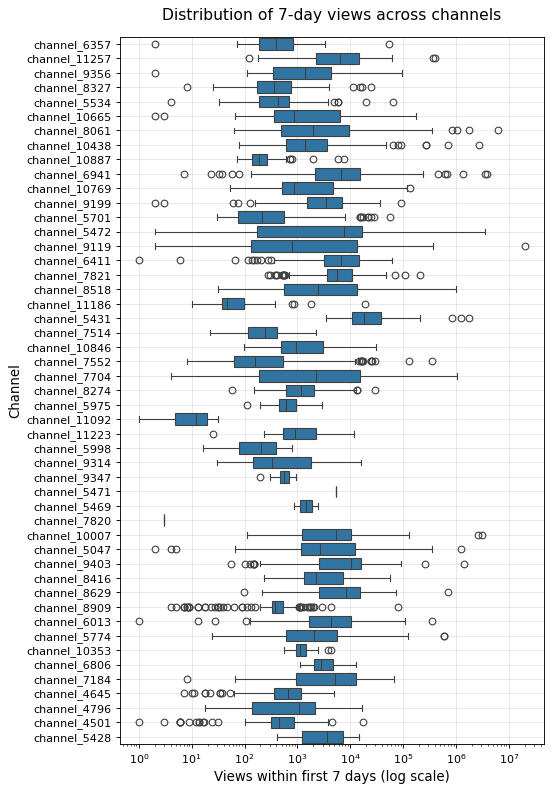

In [13]:
fig, ax = plt.subplots(figsize=(7, 10), dpi=80)

sns.boxplot(
    data=insight_data, y="channel_id", x="first_7d_views", log_scale=True, ax=ax
)

ax.set_title("Distribution of 7-day views across channels", fontsize=14, pad=15)
ax.set_xlabel("Views within first 7 days (log scale)", fontsize=12)
ax.set_ylabel("Channel", fontsize=12)
ax.grid(alpha=0.3)

plt.tight_layout()

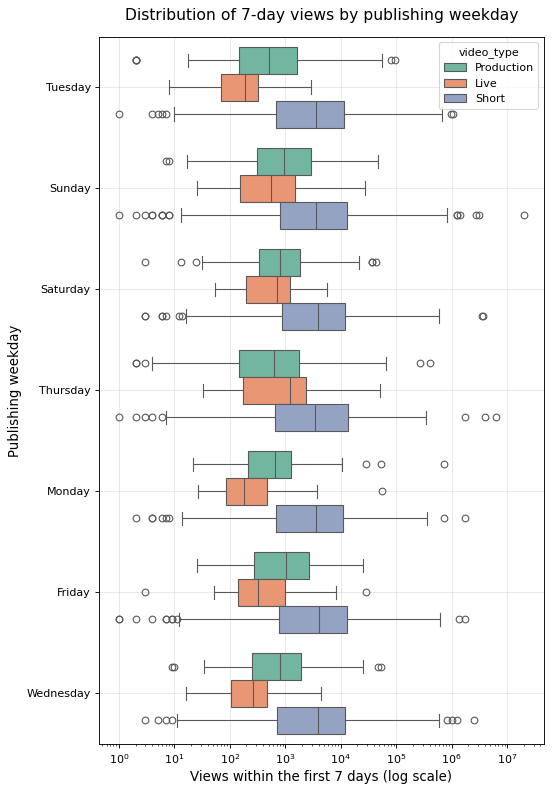

In [14]:
fig, ax = plt.subplots(figsize=(7, 10), dpi=80)

sns.boxplot(
    data=insight_data,
    y="publish_weekday",
    x="first_7d_views",
    log_scale=True,
    ax=ax,
    hue="video_type",
    palette="Set2",
)

ax.set_title("Distribution of 7-day views by publishing weekday", fontsize=14, pad=15)
ax.set_xlabel("Views within the first 7 days (log scale)", fontsize=12)
ax.set_ylabel("Publishing weekday", fontsize=12)
ax.grid(alpha=0.3)

plt.tight_layout()

### Bayesian model specification

For each video \(i\):

$$
y_i = \log(1 + \text{views}_{i,7d})
$$

$$
y_i \sim \mathcal{N}(\mu_i, \sigma_{obs})
$$

$$
\mu_i = \alpha + \delta_{d[i]} + \phi_{f[i]}
$$

where  
- $\delta_{d[i]}$ is the publishing weekday  
- $\phi_{f[i]}$ is the video format.

---

### Global intercept

$$
\alpha \sim \mathcal{N}(\bar{y}, 2.0)
$$

---

### Hierarchical effects (non-centered parameterization with sum-to-zero constraint)

Weekday effects:

$$
z^{(day)}_j \sim \mathcal{N}(0,1)
$$

$$
\delta_j = \sigma_{day}\left(z^{(day)}_j - \bar{z}^{(day)}\right)
$$

Format effects:

$$
z^{(format)}_k \sim \mathcal{N}(0,1)
$$

$$
\phi_k = \sigma_{format}\left(z^{(format)}_k - \bar{z}^{(format)}\right)
$$

---

### Hyperpriors

$$
\sigma_{day} \sim \text{HalfNormal}(0.15)
$$

$$
\sigma_{format} \sim \text{HalfNormal}(0.7)
$$

$$
\sigma_{obs} \sim \text{HalfNormal}(1.0)
$$

---

### Uplift interpretation

The percentage uplift for a weekday or format is computed from posterior samples as

$$
\text{uplift} = 100 \cdot \left(e^{\text{effect}} - 1\right)
$$

# Model and Results

In [15]:
fit_result = fit_bayesian_views_model(df=insight_data)

Sampling: [alpha, day_raw, format_raw, log_views_obs, sigma_day, sigma_format, sigma_obs]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, sigma_day, sigma_format, sigma_obs, day_raw, format_raw]


Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 41 seconds.
There were 19 divergences after tuning. Increase `target_accept` or reparameterize.
Sampling: [log_views_obs]


In [16]:
day_uplift_df, format_uplift_df = build_uplift_tables(
    idata=fit_result["idata"],
    day_names=fit_result["day_uniques"],
    format_names=fit_result["format_uniques"],
)

In [17]:
day_uplift_df

,publish_weekday,median_uplift_pct,low_95_pct,high_95_pct
2,Saturday,4.239576,-2.735647,15.860179
3,Sunday,3.758233,-3.093239,14.501458
0,Friday,3.434843,-3.116041,14.388359
6,Wednesday,-0.406204,-8.214137,7.355359
4,Thursday,-2.121129,-11.054637,4.697378
1,Monday,-3.931263,-13.565214,2.893855
5,Tuesday,-4.270811,-13.969882,2.589175


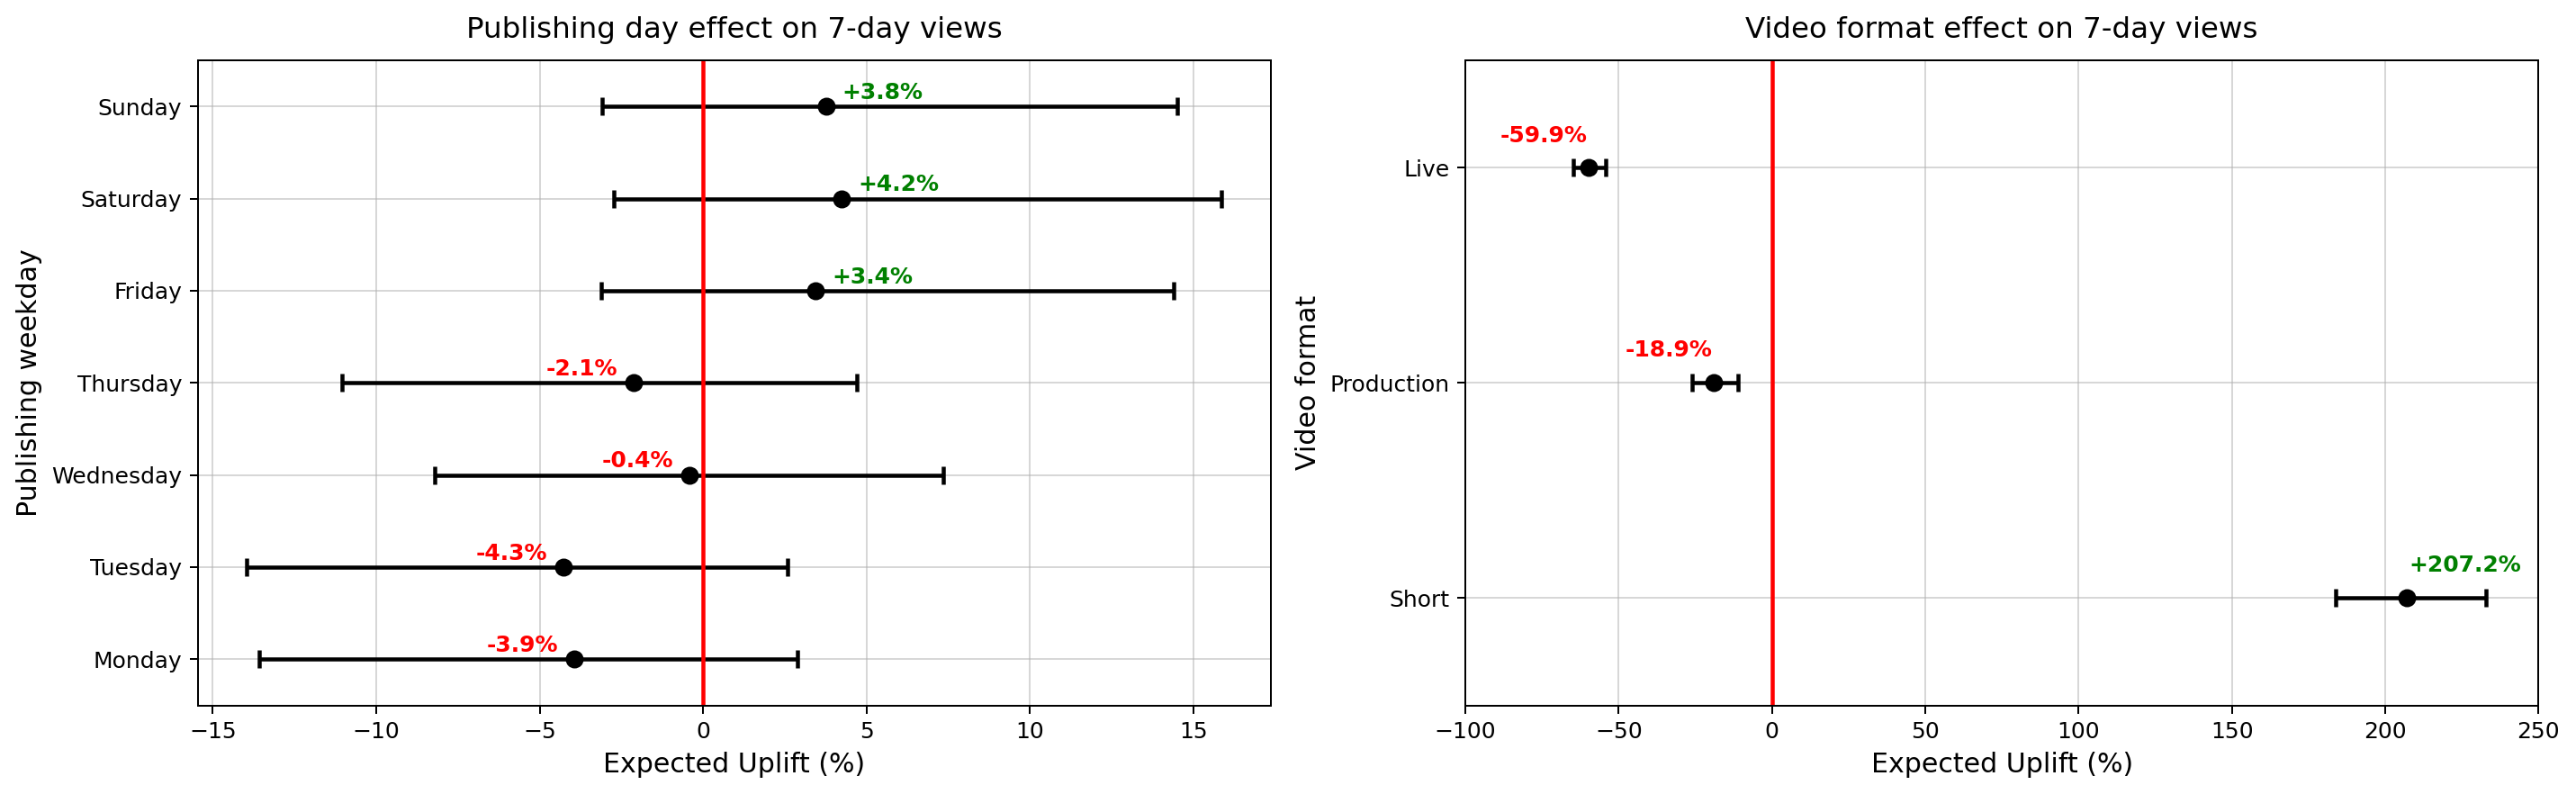

In [18]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

format_order = format_uplift_df["video_type"].tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 5), dpi=180)

plot_uplift_errorbars(
    df=day_uplift_df,
    category_col="publish_weekday",
    ax=axes[0],
    order=weekday_order,
    ylabel="Publishing weekday",
    title="Publishing day effect on 7-day views",
)

plot_uplift_errorbars(
    df=format_uplift_df,
    category_col="video_type",
    ax=axes[1],
    order=format_order,
    ylabel="Video format",
    title="Video format effect on 7-day views",
)

axes[1].set_xlim((-100, 250))

plt.tight_layout()
plt.show()

## Lets Compare Monday vs Saturday

In [19]:
build_pairwise_uplift(
    idata=fit_result["idata"],
    coord_name="day",
    baseline="Monday",
    comparison="Saturday",
)

,comparison,median_uplift_pct,low_95_pct,high_95_pct,prob_gt_zero
0,Saturday vs Monday,8.772961,-2.530052,29.050609,0.90225


### Insights
- Timing isn’t the main driver of performance, but it’s still worth optimizing. Publishing on stronger days (e.g. weekends) can deliver roughly ~10% more views than weaker days.
- Format is the real lever here. Shorts dominate the distribution — they generate about 3× the views compared to other formats.

# Insight 2: Content Lifetime from Cohort Decay


### Intro
Insight 2 estimates content lifetime from cohort trajectories in dataset 2 using a linearized form of saturation dynamics.

### Saturation Formula
$$
V(t) = V_{\text{SAT}}\left(1 - e^{-t/\tau}\right)
$$
$$
\log\left(1 - \frac{V(t)}{V_{\text{SAT}}}\right) = -\frac{t}{\tau}
$$
Here, $\tau$ is the characteristic content lifetime (time constant).
In the linear fit, slope = $-1/\tau$, so lifetime is estimated as $\tau = -1/\text{slope}$.

In [20]:
min_duration_th = 4
ratio_eps = 1e-6
min_abs_slope = 1e-3
max_life_time_months = 24

In [21]:
insight_data = prepare_half_life_regression_data(
    video_cohort_data=video_cohort_data,
    min_duration_months=min_duration_th,
    ratio_eps=ratio_eps,
)

In [22]:
coef_df = estimate_life_time_linear(
    prepared_data=insight_data,
    min_unique_months=2,
    min_abs_slope=min_abs_slope,
    max_life_time_months=max_life_time_months,
)

insight_data = insight_data.merge(
    coef_df[["video_id", "platform", "life_time"]],
    on=["video_id", "platform"],
    how="left",
)

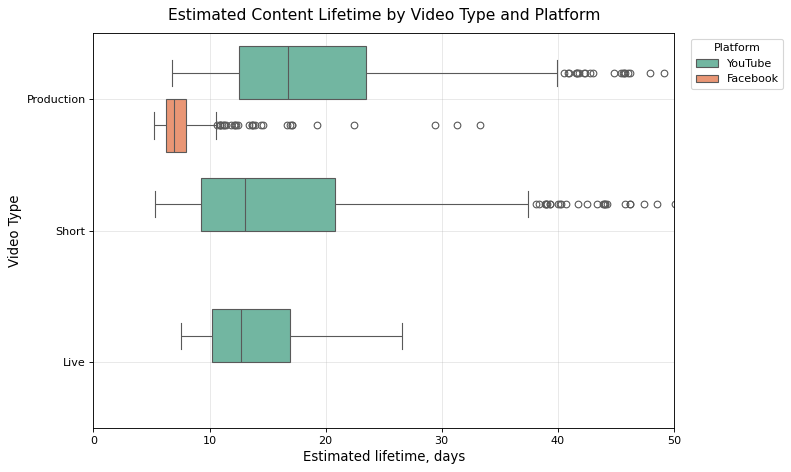

In [23]:
life_time_plot_data = build_life_time_plot_data(
    data_with_life_time=insight_data,
    lower_q=0.01,
    upper_q=0.99,
)

days_per_month = 30.4375
life_time_plot_data["life_time_days"] = (
    life_time_plot_data["life_time"] * days_per_month
)

fig, ax = plt.subplots(figsize=(10, 6), dpi=80)

sns.boxplot(
    data=life_time_plot_data,
    y="video_type",
    x="life_time_days",
    hue="platform",
    ax=ax,
    palette="Set2",
)

ax.set_title(
    "Estimated Content Lifetime by Video Type and Platform", fontsize=14, pad=12
)
ax.set_xlabel("Estimated lifetime, days", fontsize=12)
ax.set_ylabel("Video Type", fontsize=12)
ax.grid(alpha=0.3)
ax.legend(title="Platform", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_xlim((0, 50))

plt.tight_layout()
plt.show()

In [24]:
life_time_stats = (
    life_time_plot_data.groupby(["video_type", "platform"], as_index=False)
    .agg(
        median_life_time_days=("life_time_days", "median"),
        mean_life_time_days=("life_time_days", "mean"),
        std_life_time_days=("life_time_days", "std"),
        p90_life_time_days=("life_time_days", lambda s: s.quantile(0.90)),
        n=("life_time_days", "size"),
    )
    .sort_values(["video_type", "platform"])
)

life_time_stats["sem_life_time_days"] = life_time_stats["std_life_time_days"] / np.sqrt(
    life_time_stats["n"]
)

life_time_stats

,video_type,platform,median_life_time_days,mean_life_time_days,std_life_time_days,p90_life_time_days,n,sem_life_time_days
0,Live,YouTube,12.738601,14.209027,5.243166,22.707177,49,0.749024
1,Production,Facebook,6.923098,7.910900,5.600455,9.666655,479,0.255891
2,Production,YouTube,16.776182,20.328942,13.156505,33.999036,690,0.500860
3,Short,YouTube,13.050933,19.408100,17.817586,38.380024,891,0.596912


### Conclusion and Insight
- Content on Facebook seems to “burn out” much faster than on YouTube — typical lifetime is ~6–7 days vs ~15–20 days.

# Insight 3: Platform Mix Across Popularity Tiers


### Intro
Insight 3 examines how platform-level view distributions change across popularity tiers, and whether top-tail performance is platform-specific.

In [25]:
insight3_data, insight3_meta = prepare_popularity_tiers(
    data=cross_platform_data,
    views_col="total_views",
    platform_col="platform",
    content_col="content_original_id",
    video_col="video_id",
)

print(
    {
        "P50": round(insight3_meta["p50"], 2),
        "P90": round(insight3_meta["p90"], 2),
        "P99": round(insight3_meta["p99"], 2),
    }
)

{'P50': 2044.0, 'P90': 53319.8, 'P99': 2319043.0}


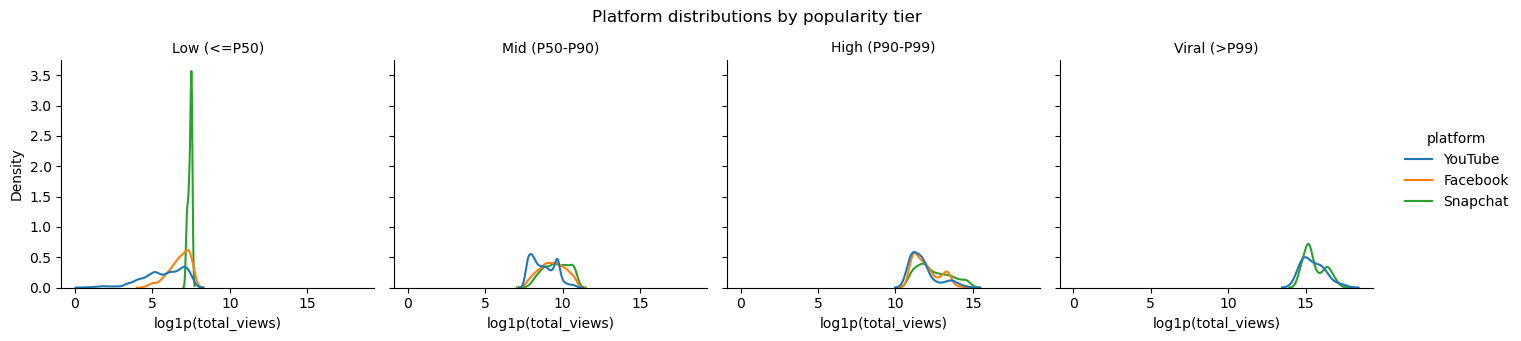

In [26]:
tier_order = insight3_meta["tier_order"]

g = sns.displot(
    data=insight3_data,
    x="log1p_views",
    hue="platform",
    col="popularity_tier",
    col_order=tier_order,
    kind="kde",
    fill=False,
    common_norm=False,
    height=3.2,
    aspect=1.1,
)
g.set_axis_labels("log1p(total_views)", "Density")
g.set_titles("{col_name}")
plt.suptitle("Platform distributions by popularity tier", y=1.05)
plt.show()

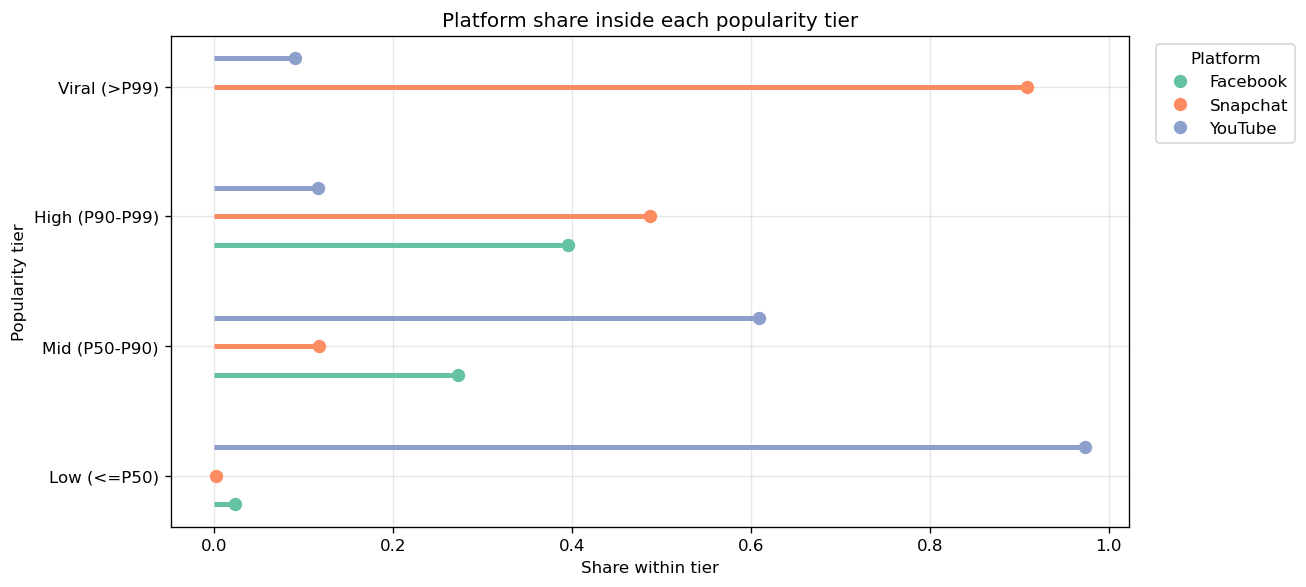

,popularity_tier,platform,videos,tier_total,tier_share,global_share,share_lift_vs_global
2,Low (<=P50),YouTube,9656,9915,0.973878,0.742181,1.312184
0,Low (<=P50),Facebook,234,9915,0.023601,0.156527,0.150776
1,Low (<=P50),Snapchat,25,9915,0.002521,0.101291,0.024893
5,Mid (P50-P90),YouTube,4831,7926,0.609513,0.742181,0.821246
3,Mid (P50-P90),Facebook,2162,7926,0.272773,0.156527,1.742654
4,Mid (P50-P90),Snapchat,933,7926,0.117714,0.101291,1.162131
7,High (P90-P99),Snapchat,870,1785,0.487395,0.101291,4.811812
6,High (P90-P99),Facebook,707,1785,0.396078,0.156527,2.530409
8,High (P90-P99),YouTube,208,1785,0.116527,0.742181,0.157006
9,Viral (>P99),Snapchat,180,198,0.909091,0.101291,8.975009


In [27]:
tier_platform = build_tier_platform_metrics(insight3_data)

plot_df = tier_platform.copy()
platform_order = sorted(plot_df["platform"].unique())
colors = sns.color_palette("Set2", n_colors=len(platform_order))
tier_to_y = {tier: i for i, tier in enumerate(tier_order)}

offsets = np.linspace(-0.22, 0.22, len(platform_order))
fig, ax = plt.subplots(figsize=(11, 5), dpi=120)

for color, platform, offset in zip(colors, platform_order, offsets):
    sub = plot_df[plot_df["platform"] == platform].copy()
    sub["tier_rank"] = sub["popularity_tier"].map(tier_to_y)
    sub = sub.sort_values("tier_rank")

    y = sub["tier_rank"].to_numpy(dtype=float) + offset
    x = sub["tier_share"].to_numpy(dtype=float)

    ax.hlines(y=y, xmin=0, xmax=x, color=color, linewidth=3)
    ax.plot(x, y, "o", color=color, label=platform, markersize=7)

ax.set_yticks(range(len(tier_order)))
ax.set_yticklabels(tier_order)
ax.set_xlabel("Share within tier")
ax.set_ylabel("Popularity tier")
ax.set_title("Platform share inside each popularity tier")
ax.grid(alpha=0.3)
ax.legend(title="Platform", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

tier_platform.sort_values(["popularity_tier", "tier_share"], ascending=[True, False])

In [28]:
spread_summary = build_content_spread_summary(insight3_data)
spread_summary.sort_values(["popularity_tier", "n_platforms"])

,popularity_tier,n_platforms,contents,tier_total_contents,share
0,Low (<=P50),1,3784,3787,0.999208
1,Low (<=P50),2,3,3787,0.000792
2,Mid (P50-P90),1,5357,5473,0.978805
3,Mid (P50-P90),2,111,5473,0.020281
4,Mid (P50-P90),3,5,5473,0.000914
5,High (P90-P99),1,1364,1426,0.956522
6,High (P90-P99),2,62,1426,0.043478
7,Viral (>P99),1,192,192,1.000000


### Conclusion and Insight
- Viral content is overwhelmingly driven by Snapchat, while YouTube dominates the long tail of low-performing videos.